# KSB — Phase error analysis (φ_u and φ_b)

**φ_u** is the phase error at the upstream reference point — how many slot periods the assigned slot deviates from a "no-correction" naive projection of when the input would arrive at the buffer exit.
It captures the *structural* demand placed on the buffer by the slot assignment.

**φ_0** is the phase error at buffer entry — how many slot periods the input is ahead of its assigned slot when it enters the buffer.
It determines the *required correction* the buffer trajectory must apply.

Both are computed in `KSBSimulation.run()` as:
```python
phi_u = (assigned_slot_times - projected_no_corr) / slot_period
phi_b = (projected_no_corr_at_entry - assigned_slot_times) / slot_period
```

Positive `phi_u` means the slot is later than the naive projection (buffer must slow the input).
Positive `phi_b` means the input arrives at the buffer entry early relative to its slot (buffer must absorb the lead).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
from pathlib import Path



In [2]:
from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.planning.solvers.quintic import QuinticSolver
from ksb.planning.solvers.scurve import SCurveSolver
with open(Path('..') / 'configs' / 'system' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

solver_name = cfg.get('solver', 'quintic')
result = KSBSimulation(cfg=cfg).run(seed=42)

# ── Derived scalars ──────────────────────────────────────────────────────────
ru   = cfg['arrival_rate_ppm'] / 60.0
rd   = ru * cfg['eta_r']
rho  = ru / rd                           # utilisation (structural invariant)
Q    = 1.0 / (1.0 - rho) if rho != 1.0 else float('inf')                 # theoretical skip cadence (inputs/skip)
slot_length = cfg['input_length'] * cfg['eta_s']
slot_period = slot_length / (rd * slot_length)  # = 1 / rd
slot_period = 1.0 / rd

phi_u       = result.phi_u
phi_b       = result.phi_b
skips       = result.skip_indices + 1     # input indices *after which* a slot was skipped
B           = len(phi_u)
input_idx   = np.arange(B) + 1

print(f"Solver      : {solver_name}")
print(f"Batch       : {B}")
print(f"ρ = ru/rd   : {rho:.4f}")
print(f"Q (theory)  : {Q:.2f}  inputs per skip")
print(f"Slot period : {slot_period*1000:.2f} ms")
print(f"Skip count  : {len(skips)}")
print()
print(f"φ_u — mean={phi_u.mean():.3f}  std={phi_u.std():.3f}  "
      f"range=[{phi_u.min():.3f}, {phi_u.max():.3f}]")
print(f"φ_0 — mean={phi_b.mean():.3f}  std={phi_b.std():.3f}  "
      f"range=[{phi_b.min():.3f}, {phi_b.max():.3f}]")

Solver      : ruckig
Batch       : 100
ρ = ru/rd   : 0.9091
Q (theory)  : 11.00  inputs per skip
Slot period : 363.64 ms
Skip count  : 9

φ_u — mean=0.980  std=0.299  range=[0.505, 1.483]
φ_0 — mean=1.363  std=0.299  range=[0.861, 1.838]


## φ sequences over input index

Skip events are marked with vertical dashed lines.
Post-skip compression (the dominant failure mode) appears as a sharp downward spike in `φ_0` immediately after each skip.

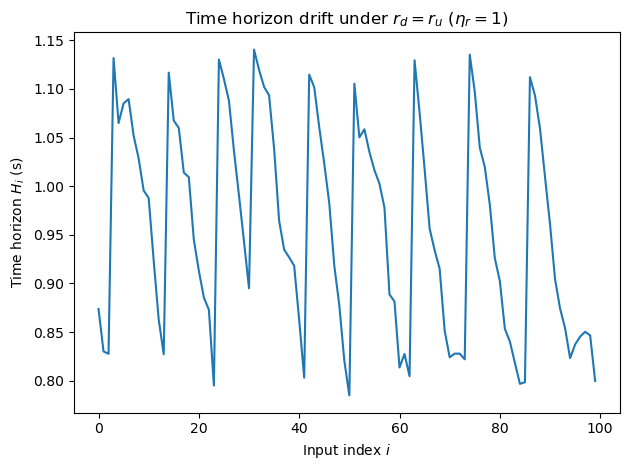

In [3]:
plt.plot(result.time_horizons)
plt.xlabel("Input index $i$")
plt.ylabel("Time horizon $H_i$ (s)")
plt.title("Time horizon drift under $r_d = r_u$ ($\\eta_r = 1$)")
plt.tight_layout()
plt.show()

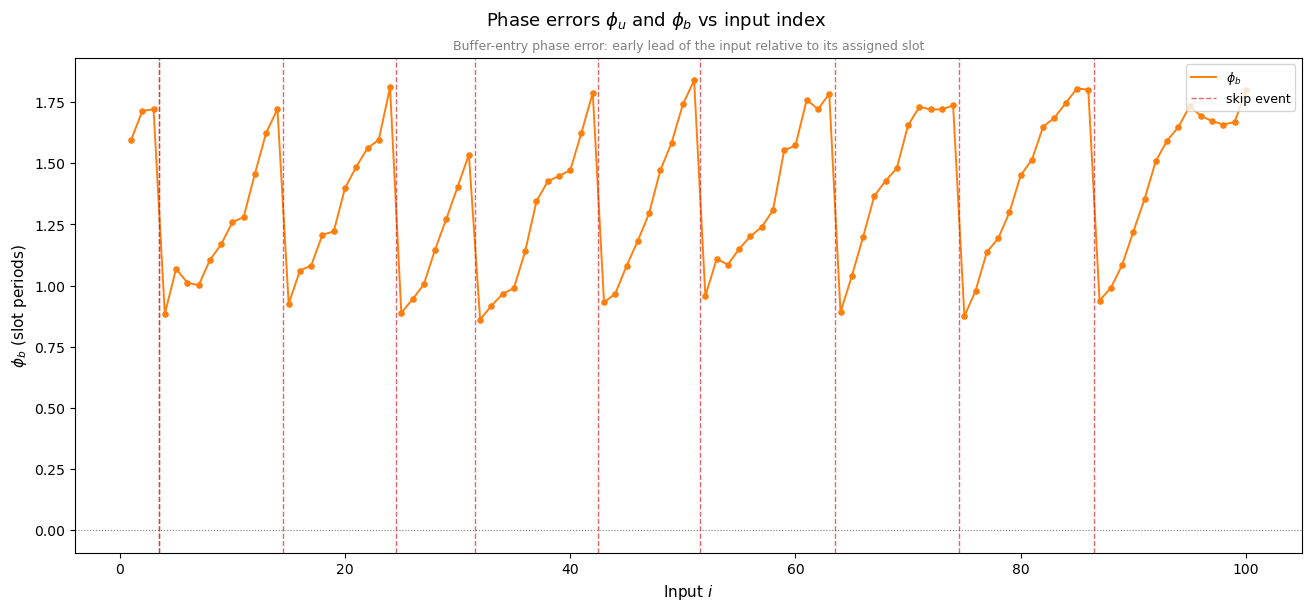

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
fig.suptitle(r'Phase errors $\phi_u$ and $\phi_b$ vs input index', fontsize=13)

SKIP_COLOR = '#d62728'
SKIP_KW    = dict(color=SKIP_COLOR, linestyle='--', linewidth=1.0, alpha=0.7)

# # ── φ_u ─────────────────────────────────────────────────────────────────────
# ax = axes[0]
# ax.plot(input_idx, phi_u, color='C0', linewidth=1.4, label=r'$\phi_u$')
# ax.scatter(input_idx, phi_u, color='C0', s=14, zorder=3)
# ax.axhline(0.0, color='gray', linewidth=0.8, linestyle=':')
# for si in skips:
#     ax.axvline(si + 0.5, **SKIP_KW)
# if len(skips):
#     ax.axvline(skips[0] + 0.5, label='skip event', **SKIP_KW)
# ax.set_ylabel(r'$\phi_u$ (slot periods)', fontsize=11)
# ax.legend(loc='upper right', fontsize=9)
# ax.set_title(
#     r'Upstream phase error: how many slot periods the assigned slot is offset from naive projection',
#     fontsize=9, color='gray'
# )

# ── φ_i ─────────────────────────────────────────────────────────────────────
ax = axes
ax.plot(input_idx, phi_b, color='C1', linewidth=1.4, label=r'$\phi_b$')
ax.scatter(input_idx, phi_b, color='C1', s=14, zorder=3)
ax.axhline(0.0, color='gray', linewidth=0.8, linestyle=':')
for si in skips:
    ax.axvline(si + 0.5, **SKIP_KW)
if len(skips):
    ax.axvline(skips[0] + 0.5, label='skip event', **SKIP_KW)
ax.set_xlabel('Input $i$', fontsize=11)
ax.set_ylabel(r'$\phi_b$ (slot periods)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.set_title(
    r'Buffer-entry phase error: early lead of the input relative to its assigned slot',
    fontsize=9, color='gray'
)

plt.show()

## Distributions of φ_u and φ_0

Both distributions are expected to be roughly uniform within a slot period in the zero-variability limit.
Non-zero gap spread ($\sigma_u > 0$) broadens them and can push `φ_0` to negative values (input arrives *late* — buffer cannot recover, producing a gap violation).

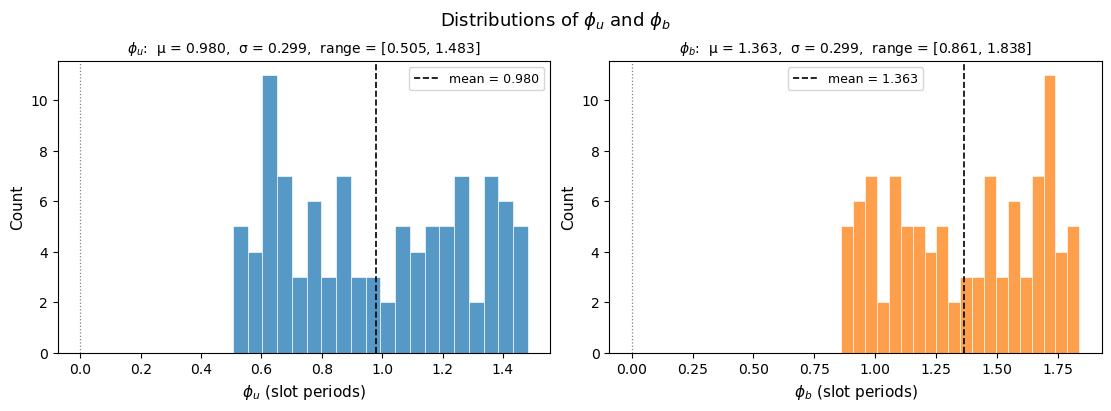

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
fig.suptitle(r'Distributions of $\phi_u$ and $\phi_b$', fontsize=13)

bins = 20

for ax, phi, label, color in [
    (axes[0], phi_u, r'$\phi_u$', 'C0'),
    (axes[1], phi_b, r'$\phi_b$', 'C1'),
]:
    ax.hist(phi, bins=bins, color=color, alpha=0.75, edgecolor='white', linewidth=0.6)
    ax.axvline(phi.mean(), color='k', linestyle='--', linewidth=1.2,
               label=f'mean = {phi.mean():.3f}')
    ax.axvline(0.0, color='gray', linestyle=':', linewidth=0.9)
    ax.set_xlabel(f'{label} (slot periods)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(
        f'{label}:  μ = {phi.mean():.3f},  σ = {phi.std():.3f},  '
        f'range = [{phi.min():.3f}, {phi.max():.3f}]',
        fontsize=10,
    )
    ax.legend(fontsize=9)

plt.show()

## φ_u vs φ_0 scatter

Each point is one input.  Skip-adjacent inputs are highlighted: the input *at* the skip (orange) and the input *immediately after* it (red).

Post-skip inputs sit in a characteristic region of the (φ_u, φ_0) plane — they have been assigned to a later slot (high φ_u) but arrive at the buffer with a small or negative lead (low φ_0), forcing maximum buffer compression.

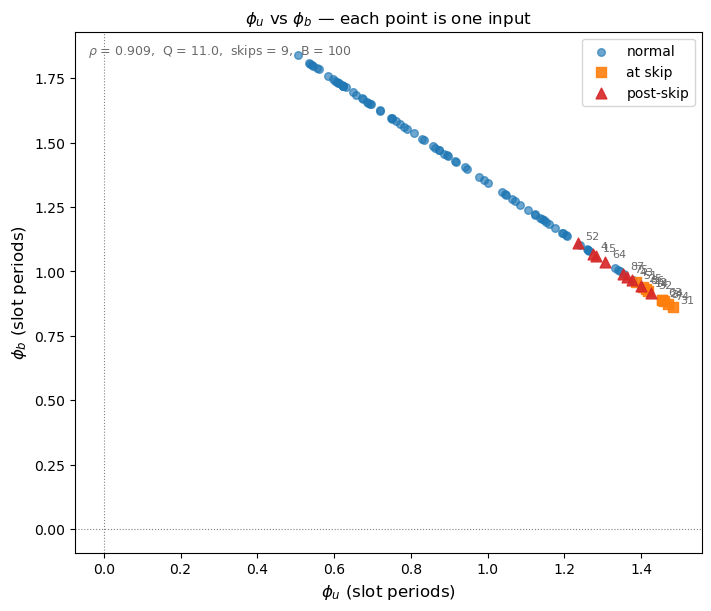

In [6]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

# Classify each input
at_skip   = np.zeros(B, dtype=bool)
post_skip = np.zeros(B, dtype=bool)
for si in skips:
    if si < B:
        at_skip[si] = True
    if si + 1 < B:
        post_skip[si + 1] = True

normal = ~at_skip & ~post_skip

ax.scatter(phi_u[normal],    phi_b[normal],    color='C0', alpha=0.65, s=30,
           label='normal', zorder=2)
ax.scatter(phi_u[at_skip],   phi_b[at_skip],   color='C1', alpha=0.9,  s=60,
           marker='s', label='at skip', zorder=4)
ax.scatter(phi_u[post_skip], phi_b[post_skip], color=SKIP_COLOR, alpha=0.9, s=60,
           marker='^', label='post-skip', zorder=4)

# Annotate index for skip-adjacent inputs
for i in np.where(at_skip | post_skip)[0]:
    ax.annotate(str(i), (phi_u[i], phi_b[i]),
                textcoords='offset points', xytext=(5, 3),
                fontsize=8, color='dimgray')

ax.axvline(0.0, color='gray', linewidth=0.8, linestyle=':')
ax.axhline(0.0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel(r'$\phi_u$ (slot periods)', fontsize=12)
ax.set_ylabel(r'$\phi_b$ (slot periods)', fontsize=12)
ax.set_title(r'$\phi_u$ vs $\phi_b$ — each point is one input', fontsize=12)
ax.legend(fontsize=10)

# Add config annotation
ax.text(
    0.02, 0.98,
    fr'$\rho$ = {rho:.3f},  Q = {Q:.1f},  skips = {len(skips)},  B = {B}',
    transform=ax.transAxes,
    fontsize=9, color='dimgray',
    va='top', ha='left',
)

plt.show()

## φ_0 vs time horizon

The time horizon `T_h` is the buffer correction window.
It should grow monotonically with `φ_0`: larger lead at entry → more time needed to synchronise.

The minimum feasible time horizon (at `φ_0 = 0`) is set by the minimum-time trajectory at constant velocity through the buffer.

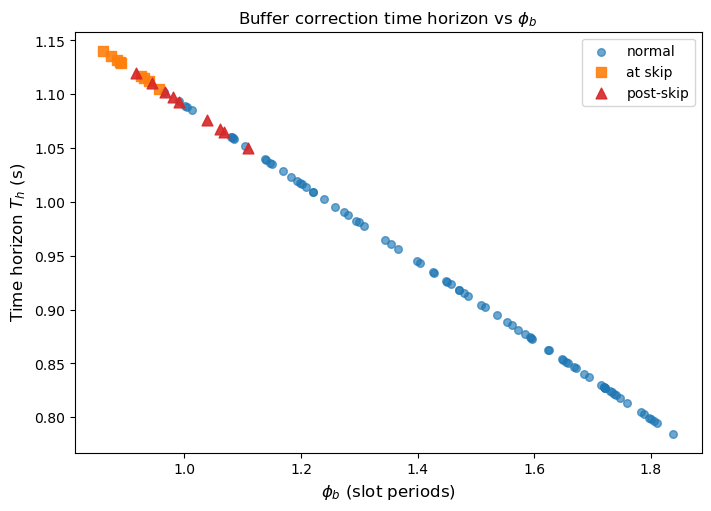

In [7]:
T_h = result.time_horizons

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax.scatter(phi_b[normal],    T_h[normal],    color='C0', alpha=0.65, s=30,
           label='normal', zorder=2)
ax.scatter(phi_b[at_skip],   T_h[at_skip],   color='C1', alpha=0.9,  s=60,
           marker='s', label='at skip', zorder=4)
ax.scatter(phi_b[post_skip], T_h[post_skip], color=SKIP_COLOR, alpha=0.9, s=60,
           marker='^', label='post-skip', zorder=4)

ax.set_xlabel(r'$\phi_b$ (slot periods)', fontsize=12)
ax.set_ylabel(r'Time horizon $T_h$ (s)', fontsize=12)
ax.set_title(r'Buffer correction time horizon vs $\phi_b$', fontsize=12)
ax.legend(fontsize=10)

plt.show()